In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../data_raw/diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
np.random.seed(42)
sample_25 = df.sample(25)


In [5]:
sample_mean = sample_25["Glucose"].mean()
sample_max = sample_25["Glucose"].max()

pop_mean = df["Glucose"].mean()
pop_max = df["Glucose"].max()


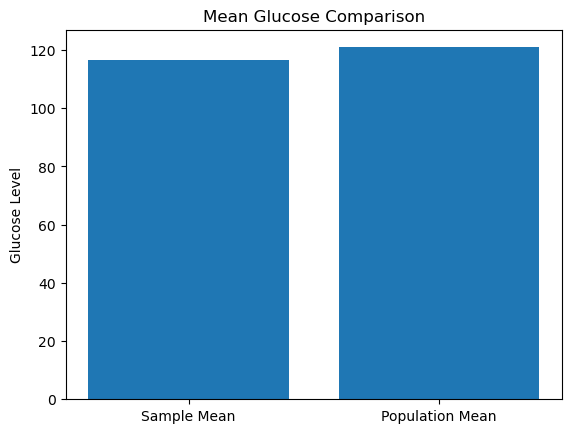

In [6]:
plt.figure()
plt.bar(["Sample Mean", "Population Mean"], [sample_mean, pop_mean])
plt.title("Mean Glucose Comparison")
plt.ylabel("Glucose Level")
plt.savefig("../results/q2_mean_glucose.png")
plt.show()


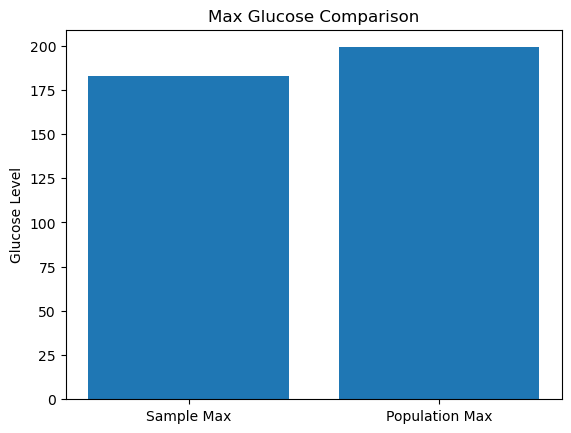

In [7]:
plt.figure()
plt.bar(["Sample Max", "Population Max"], [sample_max, pop_max])
plt.title("Max Glucose Comparison")
plt.ylabel("Glucose Level")
plt.savefig("../results/q2_max_glucose.png")
plt.show()


In [8]:
sample_bmi_98 = np.percentile(sample_25["BMI"], 98)
pop_bmi_98 = np.percentile(df["BMI"], 98)


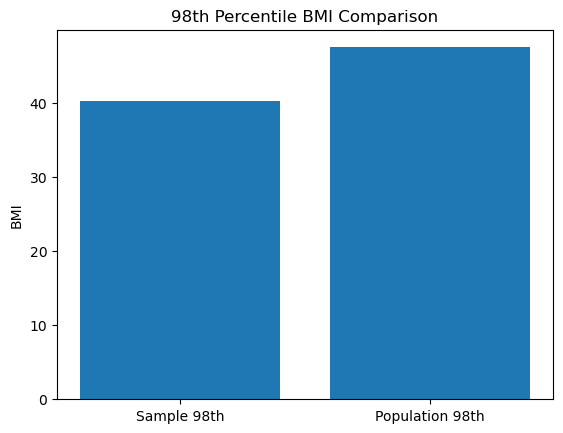

In [9]:
plt.figure()
plt.bar(["Sample 98th", "Population 98th"], [sample_bmi_98, pop_bmi_98])
plt.title("98th Percentile BMI Comparison")
plt.ylabel("BMI")
plt.savefig("../results/q2_bmi_98th.png")
plt.show()


In [10]:
boot_means = []
boot_stds = []
boot_percentiles = []

for i in range(500):
    boot_sample = df.sample(150, replace=True)
    boot_means.append(boot_sample["BloodPressure"].mean())
    boot_stds.append(boot_sample["BloodPressure"].std())
    boot_percentiles.append(np.percentile(boot_sample["BloodPressure"], 98))


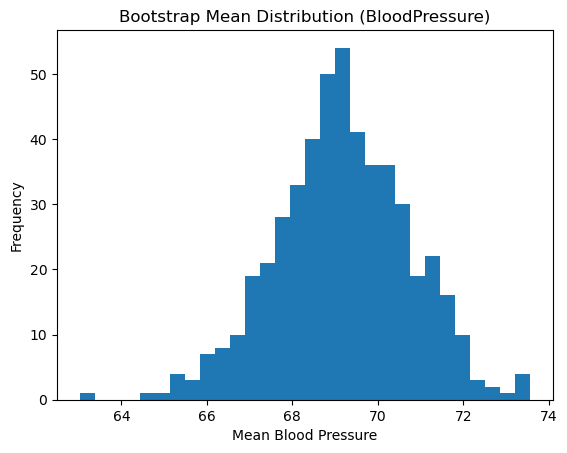

In [11]:
plt.figure()
plt.hist(boot_means, bins=30)
plt.title("Bootstrap Mean Distribution (BloodPressure)")
plt.xlabel("Mean Blood Pressure")
plt.ylabel("Frequency")
plt.savefig("../results/q2_bootstrap_bp_means.png")
plt.show()


In [12]:
df.to_csv("../data_clean/diabetes_clean.csv", index=False)